In [215]:
# import the dependency
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [216]:
pd.set_option('display.max_columns',None) # bütün sütunları göster araya ... atma
sns.set_style('whitegrid')

In [217]:
# load the dataset
df=pd.read_csv('./data/german_credit_data.csv')

lil look to dataset

In [218]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [219]:
df['Age'].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [220]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [221]:
df.shape

(1000, 11)

In [222]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 115.1 KB


In [223]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [224]:
df['Job'].unique() # status getting important 0 to 3

array([2, 1, 3, 0])

In [225]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [226]:
df.duplicated().sum() #to see the duplicated rows 

np.int64(0)

In [227]:
df=df.dropna()
# df.drop(replace=True)

In [228]:
df.shape

(522, 11)

In [229]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
7,7,35,male,3,rent,little,moderate,6948,36,car,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad


SOME PLOTS

In [230]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [231]:
df=df.drop(columns='Unnamed: 0')
# df.drop(columns='Unnamed: 0', inplace=True)

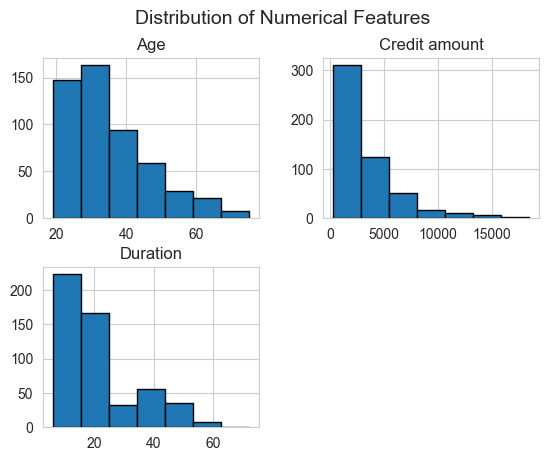

<Figure size 10000x10000 with 0 Axes>

In [232]:
df[['Age', 'Credit amount', 'Duration']].hist(bins=7,edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.figure(figsize=(10,10),dpi=1000)
plt.show()

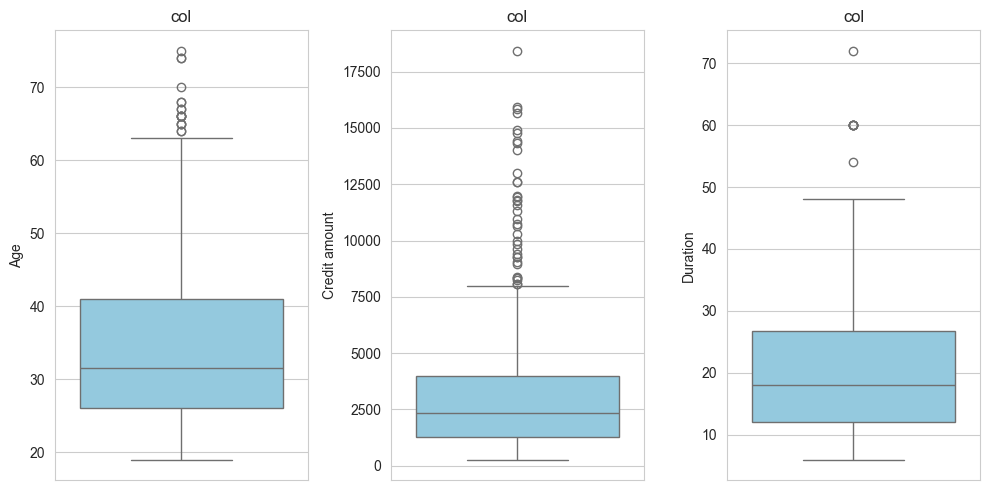

In [233]:

plt.figure(figsize=(10,5))
for i, col in enumerate(['Age','Credit amount','Duration']):
    plt.subplot(1,3, i+1) # 1 satır 3 sütün i+1 de index için
    sns.boxplot(y=df[col],color='skyblue')
    plt.title('col')
    
plt.tight_layout() # grafikler üst üste binmesin diye otamatik pozisyon ayarlar
plt.show()

# lower_bound= median- (1.5*(q3-q1))
# upper_bound= median+ (1.5*(q3-q1))

In [234]:
df.query('Duration>50')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
95,58,male,2,rent,little,moderate,15945,54,business,bad
332,24,female,3,own,moderate,moderate,7408,60,car,bad
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
714,27,male,3,own,little,moderate,14027,60,car,bad
938,42,male,2,free,little,moderate,6288,60,education,bad
973,36,male,2,rent,little,little,7297,60,business,bad


In [235]:
categorical_cols=['Sex','Job','Housing','Saving accounts', 'Checking account','Purpose',]

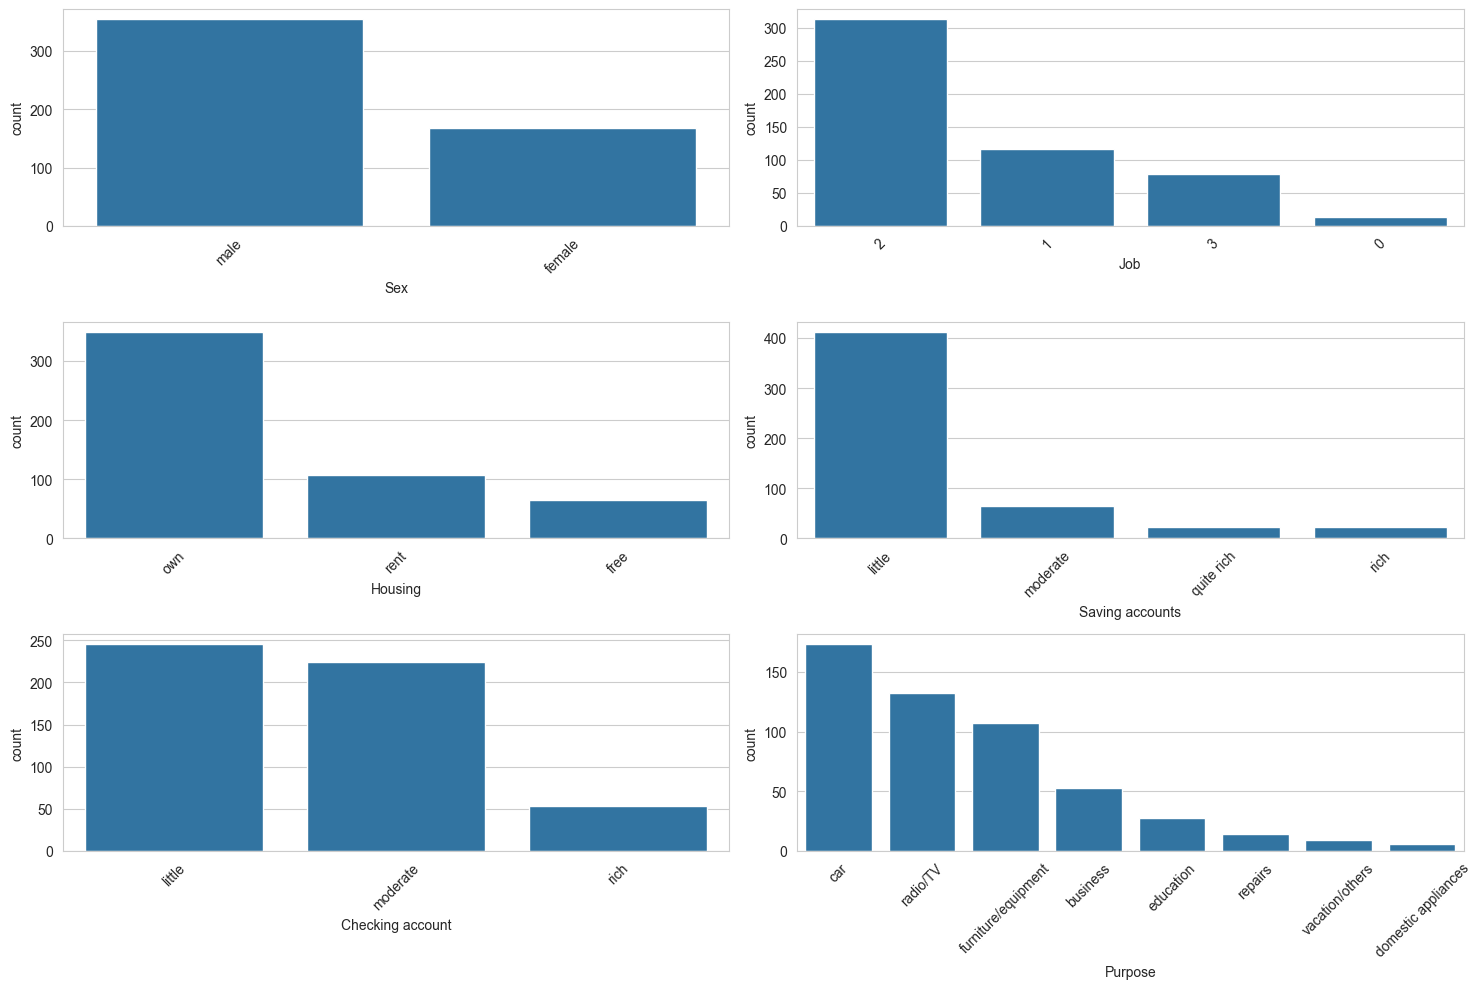

In [236]:
plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,2,i+1)
    # farklı renk kombinleri için palette='Set2' fln
    sns.countplot(data=df, x=col ,order= df[col].value_counts().index) 
    plt.xticks(rotation=45)#etiketleri çevirir iç içe girmesin diye
    

plt.tight_layout()
plt.show()

In [237]:
corr=df[['Age','Job','Credit amount','Duration']].corr()
corr
# sayısal değişkenler arasında güçlü bir ilşki yoktur

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


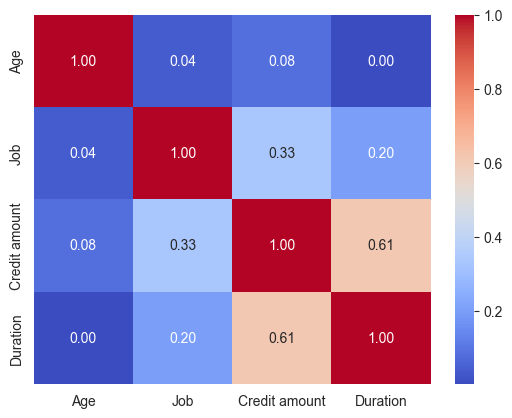

In [238]:
sns.heatmap(corr,annot=True, cmap='coolwarm', fmt='.2f') 
# annot annotation açıklma demek hücre içine sayısal değerleri yazar
#cmap color map stil
#fmt =format virgülden sonraki basamaklar
plt.show() 
# no strong relation between numerical features
# only credit amount and duration has a lil strong relation if credit amount go up duration go up gnrlly

In [239]:
df.groupby('Job')['Credit amount'].mean()
df.groupby('Job')['Credit amount'].agg(['mean','count','sum'])

,mean,count,sum
Job,,,
0,1767.857143,14,24750
1,2250.715517,116,261083
2,3129.130990,313,979418
3,5648.784810,79,446254


In [240]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [241]:
df.pivot_table( values='Credit amount',index='Housing',columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


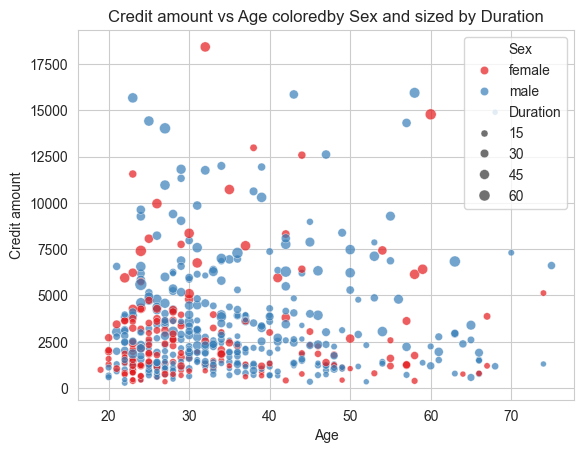

In [242]:
sns.scatterplot(data=df,x='Age', y='Credit amount', hue='Sex', size='Duration', alpha=0.7,palette='Set1')
# hue= group size noktaların büyüklüğü gruba göre yine
plt.title('Credit amount vs Age coloredby Sex and sized by Duration')
plt.show()

C:\Users\computeer\AppData\Local\Temp\ipykernel_7516\1174867438.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Saving accounts', y='Credit amount',palette='Pastel1')


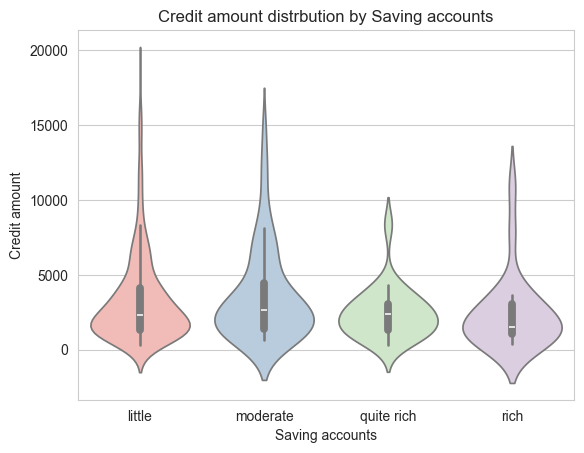

In [243]:
sns.violinplot(data=df, x='Saving accounts', y='Credit amount',palette='Pastel1')
plt.title('Credit amount distrbution by Saving accounts')
plt.show()

In [244]:
df['Risk'].value_counts(normalize=True)*100 # yüzde ver

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

In [245]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

C:\Users\computeer\AppData\Local\Temp\ipykernel_7516\789597355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2')
C:\Users\computeer\AppData\Local\Temp\ipykernel_7516\789597355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2')
C:\Users\computeer\AppData\Local\Temp\ipykernel_7516\789597355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2')


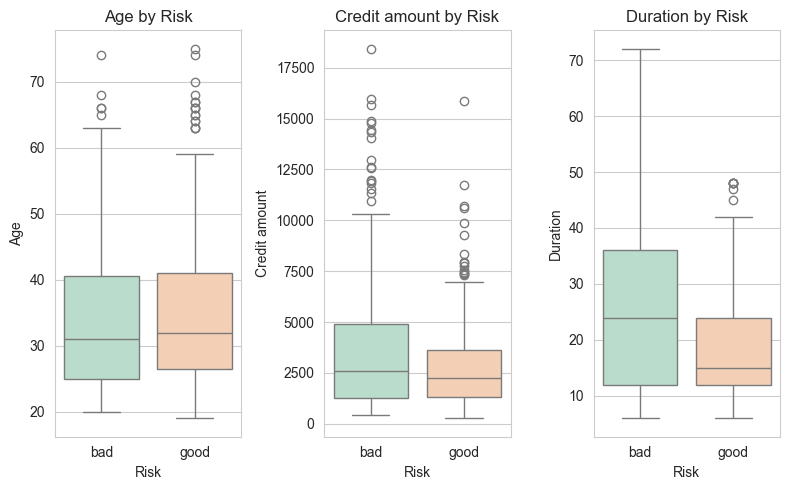

In [246]:
# risklere göre(bad ,good) age credit amount ve duration dağılımı
plt.figure(figsize=(8,5))
for i, col in enumerate(['Age','Credit amount','Duration']):
    plt.subplot(1,3, i+1) # 1 satır 3 sütün i+1 indeks numarası
    sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2')
    plt.title(f'{col} by Risk')

plt.tight_layout() # üst üste binmesin diye
plt.show()

In [247]:
df.groupby('Risk')[['Age','Credit amount','Duration']].agg(['mean','sum'])
#df.groupby('Risk')[['Age','Credit amount','Duration']].mean()

Age        Credit amount           Duration      
           mean    sum          mean     sum       mean   sum
Risk                                                         
bad   34.147186   7888   3881.090909  896532  25.445887  5878
good  35.477663  10324   2800.594502  814973  18.079038  5261

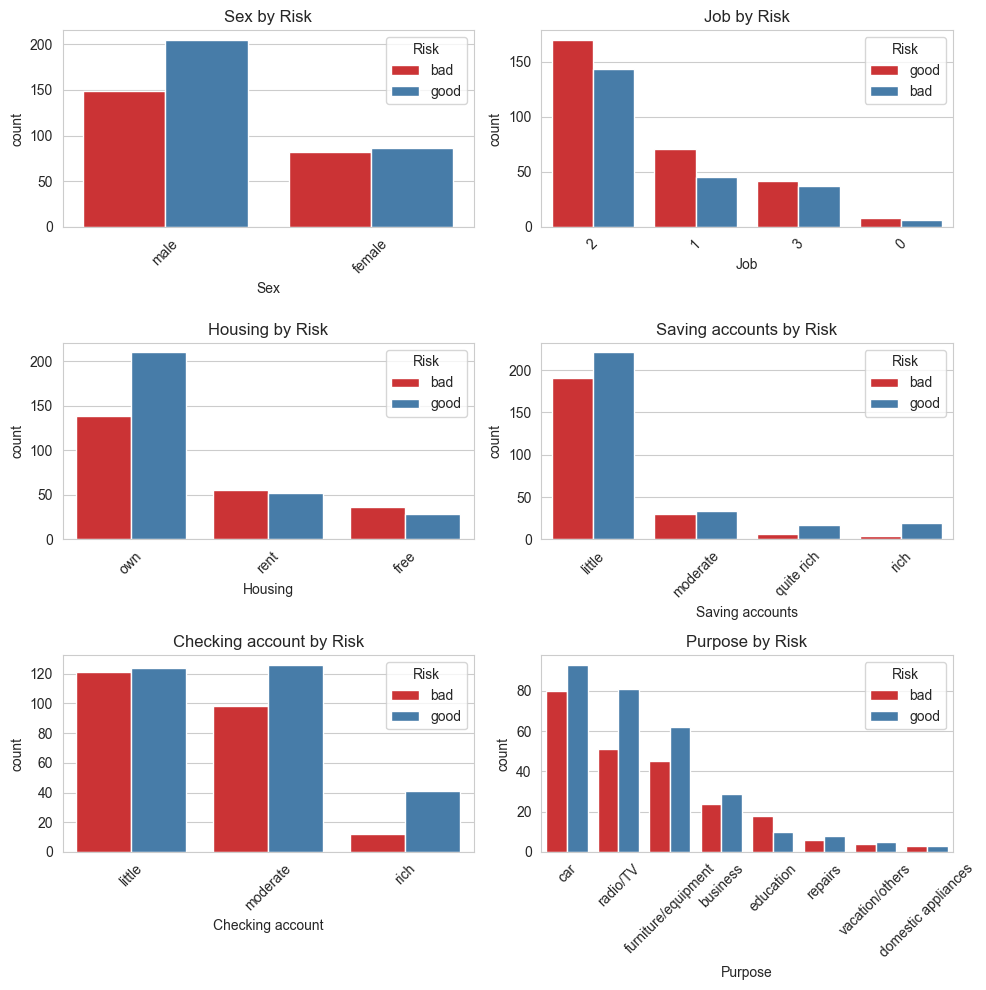

In [248]:
plt.figure(figsize=(10,10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3,2, i+1)
    sns.countplot(data=df, x=col,hue='Risk',palette='Set1', order= df[col].value_counts().index)
    plt.title(f'{col} by Risk')
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()
    

FEATURE ENGINNERING

In [249]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [250]:
features=['Age','Sex','Job','Housing','Saving accounts','Checking account','Credit amount','Duration']


In [251]:
target='Risk'

In [252]:
df_model=df[features+ [target]].copy() # to prevent the pointer stuff dont want to change orgnl df


In [253]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
1,22,female,2,own,little,moderate,5951,48,bad
3,45,male,2,free,little,little,7882,42,good
4,53,male,2,free,little,little,4870,24,bad
7,35,male,3,rent,little,moderate,6948,36,good
9,28,male,3,own,little,moderate,5234,30,bad


In [254]:
df_model.shape

(522, 9)

In [255]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [256]:
cat_cols=df_model.select_dtypes(include='object').columns.drop('Risk') 
# include object derken kategorik değişkenleri seçiyon
#.columns derken bu sütün isimlerini seçiyon ve riski atıyon

C:\Users\computeer\AppData\Local\Temp\ipykernel_7516\3517402307.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df_model.select_dtypes(include='object').columns.drop('Risk')


In [257]:
le_dict={}

In [258]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [259]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col]) # kategorik sütünu indexlicem
    le_dict[col]=le 
    #Dönüşümü yapıp geçmiyorsun, her sütun için hangi sayının hangi kelimeye geldiğini bir 
    # sözlükte (dict) tutuyorsun. İleride model bir tahmin yapıp "0" dediğinde, 
    # "0 neydi  diye bakabilmek için bu sözlük şart.
    joblib.dump(le, f'{col}_encoder.pkl')
    #Burası işin Machine Learning Engineering kısmı. Bu .pkl dosyaları senin "hafıza kartların".
    
    #Neden yapıyoruz? Yarın bir gün bu modeli bir web sitesine veya mobil uygulamaya bağladığında,
    # yeni bir müşteri gelip "Saving accounts: Rich" dediğinde, sistemin o "Rich" kelimesini tam 
    # olarak eğitimde kullandığın sayıya çevirmesi gerekecek. Kaydettiğin bu dosyayı joblib.load 
    # ile çağırıp yeni veriyi dönüştüreceksin.
    

In [260]:
le_target= LabelEncoder()
target

'Risk'

In [261]:
df_model[target] = le_target.fit_transform(df_model[target])

In [262]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [263]:
joblib.dump(le_target, 'target_encoder.pkl')

['target_encoder.pkl']

In [264]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
1,22,0,2,1,0,1,5951,48,0
3,45,1,2,0,0,0,7882,42,1
4,53,1,2,0,0,0,4870,24,0
7,35,1,3,2,0,1,6948,36,1
9,28,1,3,1,0,1,5234,30,0


In [265]:
X=df_model.drop(target, axis=1)
Y=df_model[target]

In [266]:
X.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
1,22,0,2,1,0,1,5951,48
3,45,1,2,0,0,0,7882,42
4,53,1,2,0,0,0,4870,24
7,35,1,3,2,0,1,6948,36
9,28,1,3,1,0,1,5234,30


In [267]:
Y.head()

1    0
3    1
4    0
7    1
9    0
Name: Risk, dtype: int64

In [268]:
X_train, X_test, Y_train, Y_test =train_test_split(X,Y, test_size=0.2,stratify=Y ,random_state=1)
# stratify hedef sütunu bölerken ana kütledeki oranı bozmaz mesala
# ana kütlede yüzde 60 iyi yüzde 40 kötü train,ve teste bölerken
# buna dikkat ediyor


In [269]:
X_train.shape

(417, 8)

In [270]:
Y_train.value_counts(normalize=True)*100


Risk
1    55.635492
0    44.364508
Name: proportion, dtype: float64

In [271]:
Y_test.value_counts(normalize=True)*100

Risk
1    56.190476
0    43.809524
Name: proportion, dtype: float64

In [272]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [273]:
# ağaç tabanlı model kullanıcaz
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV # hyperparametleri kendibulsun

In [274]:
def train_model(model, param_grid, X_train, Y_train, X_test, Y_test):
    grid=GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, Y_train)
    best_model=grid.best_estimator_
    y_pred= best_model.predict(X_test)
    acc=accuracy_score(Y_test, y_pred)
    return best_model, acc, grid.best_params_

1. GridSearchCV (Modelin "En İyiyi" Arama Motoru)
Python
grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
model: Hangi algoritmayı kullanacağını söylüyorsun (RF, XGBoost vb.).

param_grid: Bu bir sözlüktür. Örneğin {'max_depth': [3, 5, 10]} dersen, model bu derinliklerin hepsini tek tek dener.

cv=5 (Cross-Validation): Veriyi 5 parçaya böler. 4 parçayla eğitir, 1 parçayla test eder. Bunu 5 kez tekrarlar. Bu sayede modelin başarısının "şans eseri" olup olmadığını anlarsın. Verinin her köşesini hem eğitim hem test için kullanmış olursun.

scoring='accuracy': Başarı kriterin. German Credit verisinde "Doğru tahmin oranı" üzerinden en iyiyi seç diyorsun.

n_jobs=-1: Bilgisayarındaki tüm işlemci çekirdeklerini (CPU) aynı anda çalıştırır. Matematik mühendisliği hesaplamalarında olduğu gibi paralel programlama yaparak zaman kazandırır.

2. grid.fit(X_train, Y_train) (Antrenman Zamanı)
Bu satır çalıştığında arka planda büyük bir kombinasyon döner. Eğer param_grid içinde 10, cv içinde 5 seçenek varsa; model tam 50 kez eğitilir ve test edilir. En sonunda "En yüksek ortalamayı veren parametre seti budur" diyerek şampiyonu belirler.

3. grid.best_estimator_ (Şampiyon Modeli Almak)
Python
best_model = grid.best_estimator_
GridSearch bittikten sonra elinde onlarca deneme olur. Bu komut, sana o denemeler içinden en iyi skoru alan eğitilmiş modeli verir. Artık tahminlerini bu "akıllı" modelle yapacaksın.

4. best_model.predict(X_test) (Gerçek Sınav)
Python
y_pred = best_model.predict(X_test)
Model eğitim sırasında X_test verisini hiç görmedi. Şimdi ona "Al bakalım bu kişilerin bilgilerini, sence kredi borçlarını öderler mi?" diyoruz. Çıkan sonuçları (y_pred), gerçek sonuçlarla (Y_test) karşılaştıracağız.

5. accuracy_score(Y_test, y_pred) (Karne Notu)
Python
acc = accuracy_score(Y_test, y_pred)
doğru/toplam
Yani 200 kişilik test setinde 160 kişiyi doğru bildiysen, acc = 0.80 olur.

6. Neden Bu 3 Şeyi Return Ediyoruz?
Python
return best_model, acc, grid.best_params_
best_model: Bunu joblib.dump ile kaydedip ilerde kullanmak için.

acc: Modelin genel başarısını anlık görmek için.

grid.best_params_: "Hangi parametreler işe yaradı?" sorusuna cevap vermek için. (Mesela ağaç derinliği 5 miymiş 10 mu?)

In [275]:
dt=DecisionTreeClassifier(random_state=1, class_weight='balanced')
dt_param_grid={
    'max_depth': [3,5,7,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf': [1,2,4]
    
}

1. En Kritik Dokunuş: class_weight='balanced'
Bu dataset üzerinde çalışan çoğu kişi bunu unutur ama sen unutmamışsın. German Credit verisinde "İyi" (Good) krediler "Kötü" (Bad) olanlardan çok daha fazla.

Sorun: Eğer bu ayarı yapmazsan, model sadece "Herkes iyidir" diyerek bile %70 doğruluk (accuracy) elde edebilir ama asıl yakalamamız gereken "Kötü"leri kaçırır.

Çözüm: balanced dediğinde, azınlıkta olan "Bad" sınıfına matematiksel olarak daha fazla ağırlık verir. Yani model, bir "Kötü"yü yanlış tahmin ettiğinde daha büyük bir ceza yer ve onu öğrenmeye zorlanır.


2. Parametrelerin "Mühendislik" Anlamları
max_depth (Maksimum Derinlik):

3 veya 5 gibi küçük değerler seçersen: Model genel kurallar öğrenir (Underfitting riski az, basit model).

None dersen: Ağaç, her bir yaprağı tertemiz yapana kadar uzar gider. Bu da modeli veriyi ezberlemeye (Overfitting) iter.

min_samples_split (Dallanma Sınırı):

Bir düğümün (node) ikiye bölünmesi için içinde en az kaç veri olması gerektiğini söyler. Bu sayıyı artırmak (mesela 10), ağacın çok küçük detaylara boğulmasını engeller.

min_samples_leaf (Yaprak Sınırı):

Ağacın en ucundaki "yapraklarda" en az kaç tane örnek kalması gerektiğini belirler. 4 yapmak, çok uç ve tekil vakalara göre karar verilmesini engeller, modeli daha genel bir yapıya kavuşturur.

In [276]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid,X_train, Y_train, X_test, Y_test)

In [277]:
print('Decision Tree Accuracy',acc_dt)

Decision Tree Accuracy 0.580952380952381


In [278]:
print('Best parameters', params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [279]:
rf=RandomForestClassifier(random_state=1, class_weight='balanced',n_jobs=-1)


In [280]:
rf_param_grid={
    'n_estimators':[100,200],
    'max_depth': [5,7,10,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

In [281]:
best_rf, acc_rf, param_rf =train_model(rf,rf_param_grid,X_train, Y_train, X_test, Y_test)

In [282]:
print('Random Forest Accuracy',acc_rf)

Random Forest Accuracy 0.6190476190476191


In [283]:
print('Best parameters',param_rf)

Best parameters {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [284]:
#extra tree
et= ExtraTreesClassifier(random_state=1, class_weight='balanced', n_jobs=1)

In [285]:
et_param_grid={
    'n_estimators':[100,200],
    'max_depth': [5,7,10,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

In [286]:
best_et, acc_et, param_et = train_model(et,et_param_grid,X_train, Y_train, X_test, Y_test)

In [287]:
print('Extra Tree Accuracy',acc_et)

Extra Tree Accuracy 0.6476190476190476


In [288]:
print('Best parameters',param_et)

Best parameters {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [289]:
xgb= XGBClassifier(random_state=1,scale_pos_weight=(Y_train==0).sum()/(Y_train==1).sum() , use_label_encoder=False, eval_metric='logloss')

knks scale_Pos_weight ağırlıklandırma için kullanılır 700/300 2.33
iyi /kötü oranı yani kötüye iyi derse -2.33 alcak 

eval_metric='logloss': İstatistiksel olarak modelin başarısını "Lojistik Kayıp" (Logarithmic Loss) üzerinden ölçüyorsun. Bu, olasılık tahminlerinin ne kadar isabetli olduğunu denetleyen harika bir metriktir.

In [290]:
xgb_param_grid={
    'n_estimators': [100,200],
    'max_depth' : [3,5,7],
    'learning_rate':[0.01,0.1,0.2],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7,1]
    
}

1. max_depth ([3, 5, 7])
Ağacın ne kadar derinleşeceğini kontrol ediyorsun.

3: Çok basit kurallar öğrenir, Underfitting (yetersiz öğrenme) riski taşır ama çok stabildir.

7: Çok detaylı kurallar öğrenir. Bizim 1000 satırlık küçük veri setinde 7 derinliği bazen Overfitting (ezberleme) yapabilir. GridSearch burada en dengeli olanı (genelde 5 çıkar) seçecektir.

2. learning_rate ([0.01, 0.1, 0.2])
Buna istatistikte "Shrinkage" (Büzülme) denir. Her yeni ağacın hatayı ne kadar "sert" düzelteceğini belirler.

0.01: Model çok yavaş öğrenir, daha fazla n_estimators (ağaç) gerektirir ama daha sağlam sonuç verir.

0.2: Model hızlı öğrenir ama bazen global minimumu ıskalayıp hata payını artırabilir.

3. subsample ve colsample_bytree ([0.7, 1])
İşte burası Stochastic Gradient Boosting kısmı!

subsample=0.7: Her ağaç eğitilirken verilerin rastgele %70'ini kullanır. Bu, modelin veri setindeki gürültüye (noise) odaklanmasını engeller.

colsample_bytree=0.7: Her ağaç eğitilirken sütunların (özelliklerin) rastgele %70'ini seçer. Bu da bazı güçlü sütunların (örneğin Credit Amount) modeli tamamen domine etmesini engeller.

In [291]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid ,X_train, Y_train, X_test, Y_test)

c:\Users\computeer\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:08:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [292]:
print("XGB Accuracy",acc_xgb)

XGB Accuracy 0.6761904761904762


In [293]:
print("Best params", params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [294]:
best_et.predict(X_test)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1])

In [295]:
joblib.dump(best_xgb,'xgb_credit_model.pkl')

['xgb_credit_model.pkl']

In [296]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
